🔹 Total PV module demand (01_SP_MV_PV): 4,567,031.00 MW
🔸 Total PV module demand (01_SP_MV_PV_new): 3,990,661.10 MW


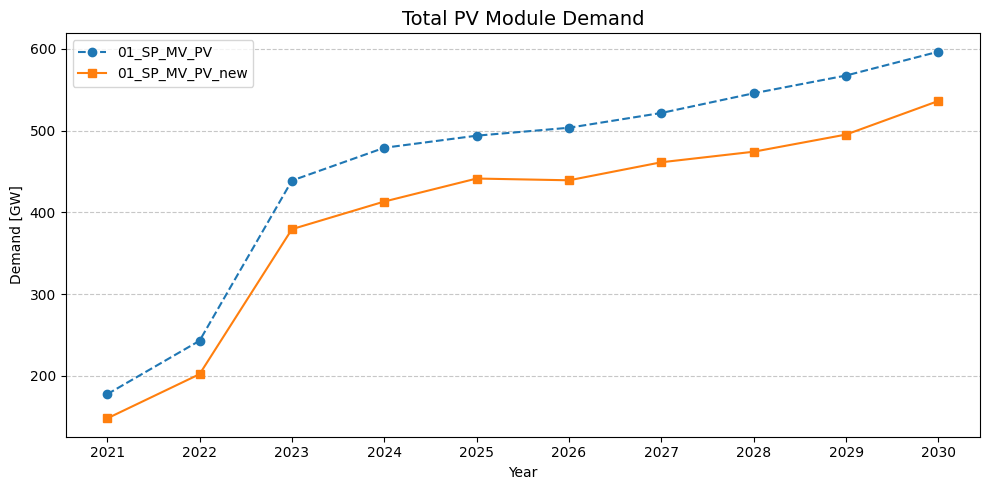

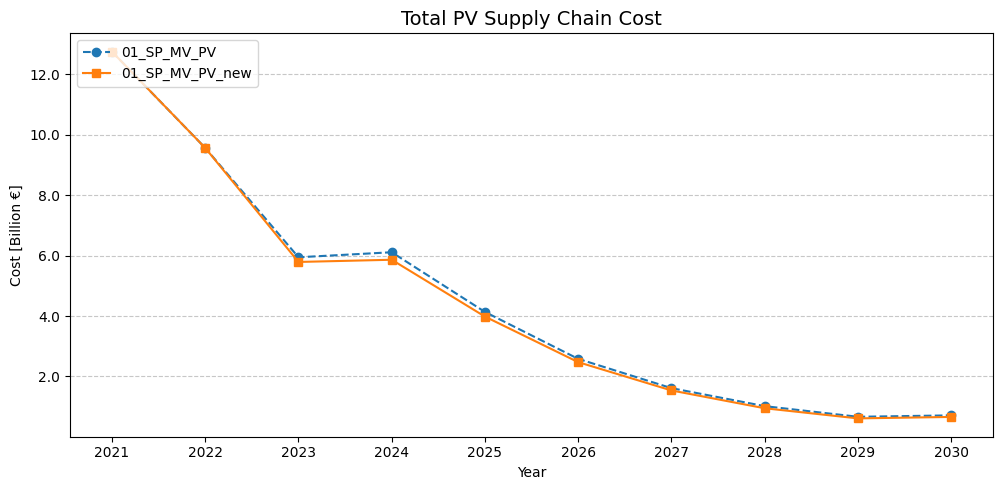

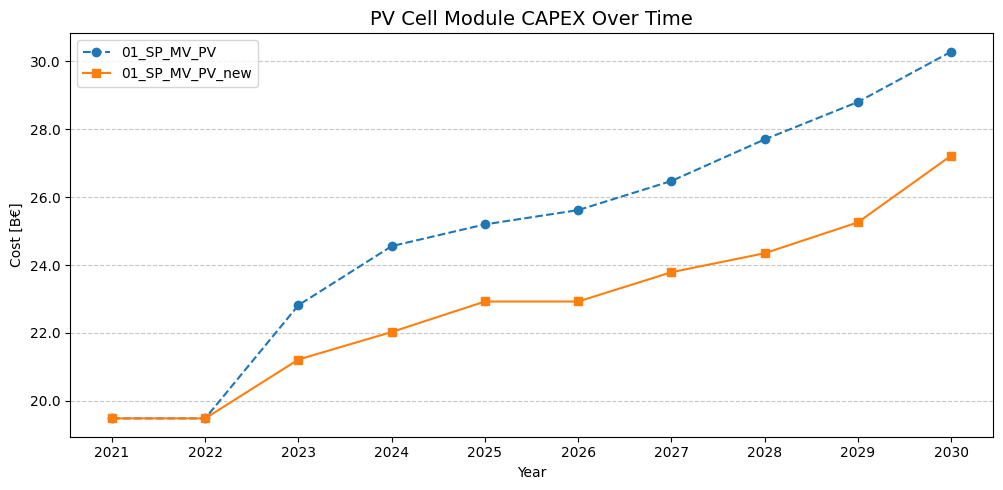

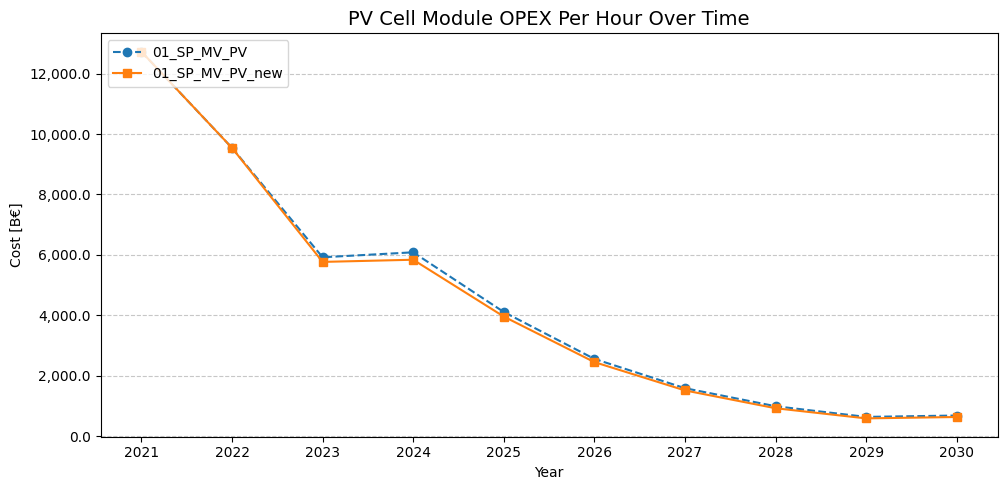

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
dataset_name_1 = '01_SP_MV_PV'
dataset_name_2 = '01_SP_MV_PV_new'
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# === Save Path Settings ===
save_plots = True
save_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\SCM_plots\pv_comparison")
csv_export_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\device_demand_data")

if save_plots:
    os.makedirs(save_path, exist_ok=True)
    os.makedirs(csv_export_path, exist_ok=True)

# === Style Settings ===
start_year = 2021
marker_styles = {dataset_name_1: 'o', dataset_name_2: 's'}
colors = {dataset_name_1: '#1f77b4', dataset_name_2: '#ff7f0e'}
linestyles = {dataset_name_1: '--', dataset_name_2: '-'}
line_widths = {dataset_name_1: 1.5, dataset_name_2: 1.5}

# === Load and Filter Demand ===
demand1 = r1.get_full_ts("demand").reset_index()
demand2 = r2.get_full_ts("demand").reset_index()

demand_pv_1 = demand1[demand1["carrier"].str.lower() == "pv_module"]
demand_pv_2 = demand2[demand2["carrier"].str.lower() == "pv_module"]

time_cols = [col for col in demand_pv_1.columns if isinstance(col, (int, float))]

# === Total Demand Plot ===
def plot_total_pv_demand():
    # Raw data assumed in MW → convert to GW just for plotting
    total1 = demand_pv_1[time_cols].sum() / 1e3  # MW → GW
    total2 = demand_pv_2[time_cols].sum() / 1e3  # MW → GW

    total_demand_1_mw = demand_pv_1[time_cols].sum().sum()
    total_demand_2_mw = demand_pv_2[time_cols].sum().sum()

    print(f"🔹 Total PV module demand ({dataset_name_1}): {total_demand_1_mw:,.2f} MW")
    print(f"🔸 Total PV module demand ({dataset_name_2}): {total_demand_2_mw:,.2f} MW")

    plt.figure(figsize=(10, 5))
    plt.plot(time_cols, total1, label=dataset_name_1, color=colors[dataset_name_1],
             linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1])
    plt.plot(time_cols, total2, label=dataset_name_2, color=colors[dataset_name_2],
             linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2])

    plt.title("Total PV Module Demand", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Demand [GW]")
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])

    if save_plots:
        plt.savefig(save_path / "pv_module_demand_total.pdf", format='pdf', bbox_inches='tight')

    plt.show()

def plot_total_pv_cost():
    cost1 = r1.get_full_ts("cost_total").reset_index()
    cost2 = r2.get_full_ts("cost_total").reset_index()

    # Filter if carrier column exists
    if "carrier" in cost1.columns:
        cost1 = cost1[cost1["carrier"].str.lower() == "pv_module"]
    if "carrier" in cost2.columns:
        cost2 = cost2[cost2["carrier"].str.lower() == "pv_module"]

    # Ensure year is calendar-based
    if "year" in cost1.columns:
        cost1["year"] = cost1["year"] + start_year
        cost2["year"] = cost2["year"] + start_year
    else:
        print("❌ 'year' column not found in cost_total data. Cannot plot.")
        return

    # Convert cost to B€
    cost1["value"] = cost1["value"] / 1e6
    cost2["value"] = cost2["value"] / 1e6

    years = sorted(set(cost1["year"]).union(set(cost2["year"])))

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(cost1["year"], cost1["value"], label=dataset_name_1, color=colors[dataset_name_1],
             linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1])
    plt.plot(cost2["year"], cost2["value"], label=dataset_name_2, color=colors[dataset_name_2],
             linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2])

    plt.title("Total PV Supply Chain Cost", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Cost [Billion €]")
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.xticks(ticks=years, labels=[str(y) for y in years])

    # Format y-axis with commas and one decimal
    ax = plt.gca()
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

    if save_plots:
        plt.savefig(save_path / "pv_module_cost_total.pdf", format='pdf', bbox_inches='tight')

    plt.show()

def plot_pv_cost_component(component_name, title, file_name, divide_by_hours=False):
    df1 = r1.get_full_ts(component_name).reset_index()
    df2 = r2.get_full_ts(component_name).reset_index()

    if "technology" in df1.columns:
        df1 = df1[df1["technology"] == "cell_pv_module"]
    if "technology" in df2.columns:
        df2 = df2[df2["technology"] == "cell_pv_module"]

    if "year" in df1.columns:
        df1["year"] = df1["year"] + start_year
        df2["year"] = df2["year"] + start_year
    else:
        print(f"❌ 'year' column not found in {component_name} data.")
        return

    # Convert from M€ → B€
    df1["value"] = df1["value"] / 1e3
    df2["value"] = df2["value"] / 1e3

    # NOTE: We ignore divide_by_hours — keeping raw annual values
    years = sorted(set(df1["year"]).union(set(df2["year"])))

    plt.figure(figsize=(10, 5))
    plt.plot(df1["year"], df1["value"], label=dataset_name_1, color=colors[dataset_name_1],
             linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1])
    plt.plot(df2["year"], df2["value"], label=dataset_name_2, color=colors[dataset_name_2],
             linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2])

    plt.title(title, fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Cost [B€]")
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.xticks(ticks=years, labels=[str(y) for y in years])

    ax = plt.gca()
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

    if save_plots:
        plt.savefig(save_path / f"{file_name}.pdf", format='pdf', bbox_inches='tight')

    plt.show()

# === Run All ===
plot_total_pv_demand()
plot_total_pv_cost()

plot_pv_cost_component(
    component_name="cost_capex_yearly_total",
    title="PV Cell Module CAPEX Over Time",
    file_name="pv_cell_module_capex"
)

plot_pv_cost_component(
    component_name="cost_opex_yearly_total",
    title="PV Cell Module OPEX Per Hour Over Time",
    file_name="pv_cell_module_opex_per_hour",
    divide_by_hours=True
)

